# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Asphalt 60°</font>

<font size="6">Test 1: (failed)</font>

Average Fx in the averaging interval [None:None]: 3.645178075327826
Average Fz in the averaging interval [None:None]: -0.9459715174678156
Maximum Fz in the plotting interval [None:None]: 0.8864339192708334 at timestep 548
Time step where Fx drops below 1: 0


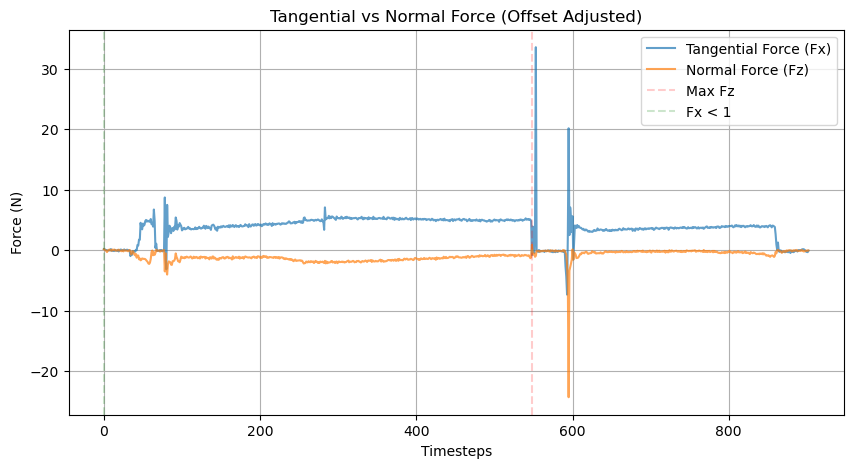

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241700.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 543
Average Fx in the averaging interval [680:1223]: 5.166784025160647
Average Fz in the averaging interval [680:1223]: 1.239099750553925
Maximum Fz in the plotting interval [680:None]: 2.3720662434895834 at timestep 1184
Time step where Fx drops below 1: 1223


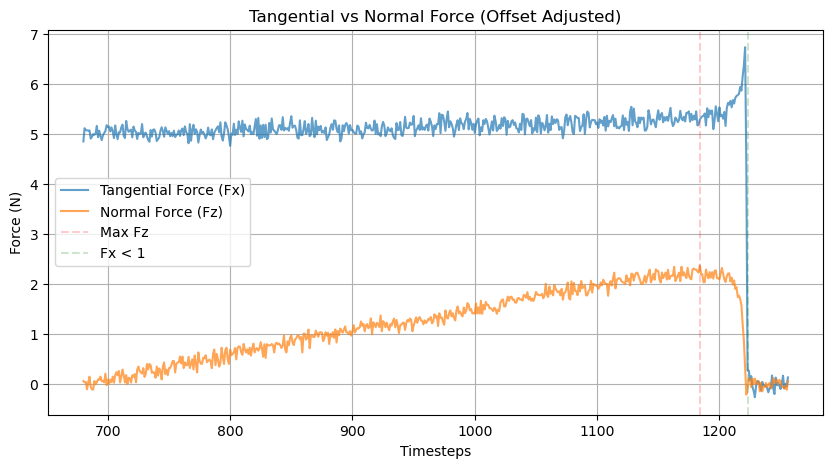

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241701.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=680, cut_2=None, avg_end=1223, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 283
Average Fx in the averaging interval [290:573]: 5.50761108785973
Average Fz in the averaging interval [290:573]: 0.30948742977721955
Maximum Fz in the plotting interval [290:600]: 0.776422119140625 at timestep 538
Time step where Fx drops below 1: 573


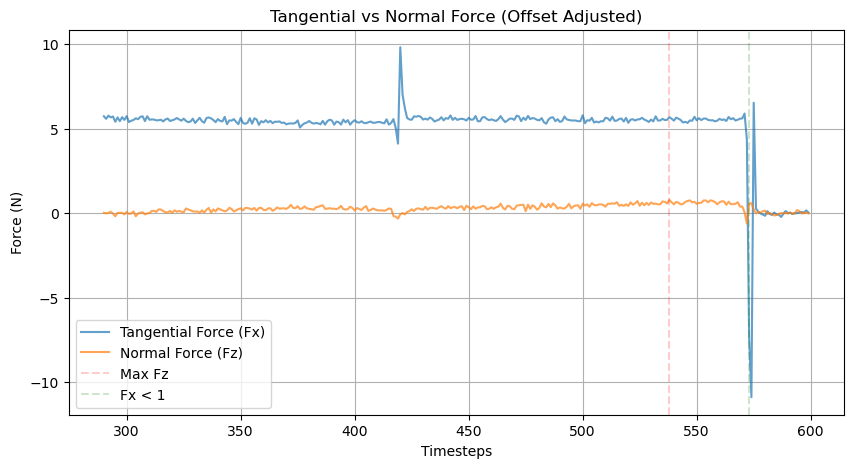

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241702.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=290, cut_2=600, avg_end=573, offset_position='end', offset_length=20)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 616
Average Fx in the averaging interval [440:1056]: 5.00135608137428
Average Fz in the averaging interval [440:1056]: 0.7602734057934253
Maximum Fz in the plotting interval [440:None]: 1.660845947265625 at timestep 1004
Time step where Fx drops below 1: 1056


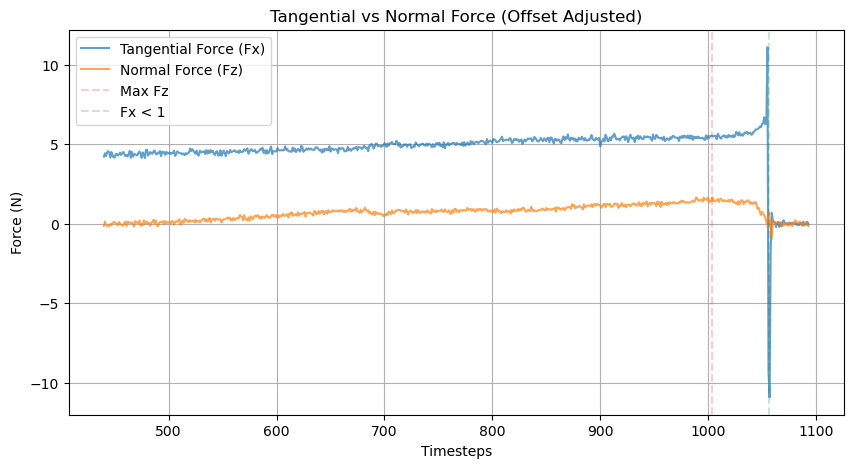

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241703.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=440, cut_2=None, avg_end=1056, offset_position='end', offset_length=20)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 671
Average Fx in the averaging interval [280:951]: 4.776442272557706
Average Fz in the averaging interval [280:951]: 0.8741066248098298
Maximum Fz in the plotting interval [280:None]: 2.508231608072917 at timestep 938
Time step where Fx drops below 1: 951


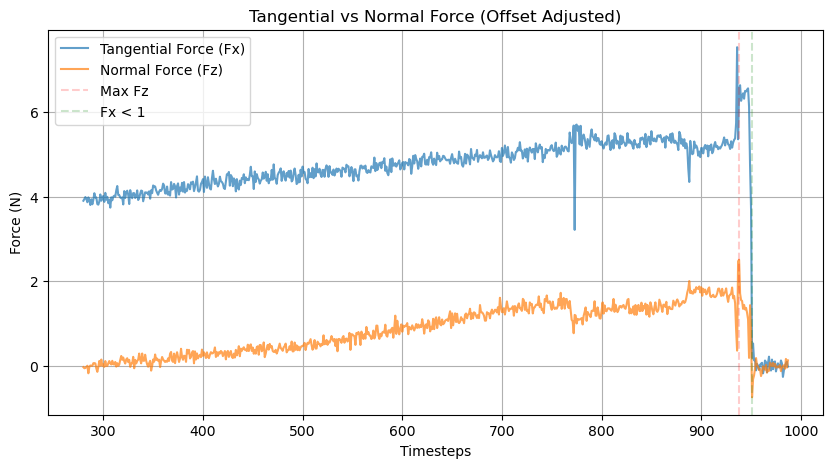

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241704.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=280, cut_2=None, avg_end=951, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 1044
Average Fx in the averaging interval [300:1344]: 5.136812159019412
Average Fz in the averaging interval [300:1344]: 1.1104470790117635
Maximum Fz in the plotting interval [300:None]: 3.539298502604167 at timestep 1341
Time step where Fx drops below 1: 1344


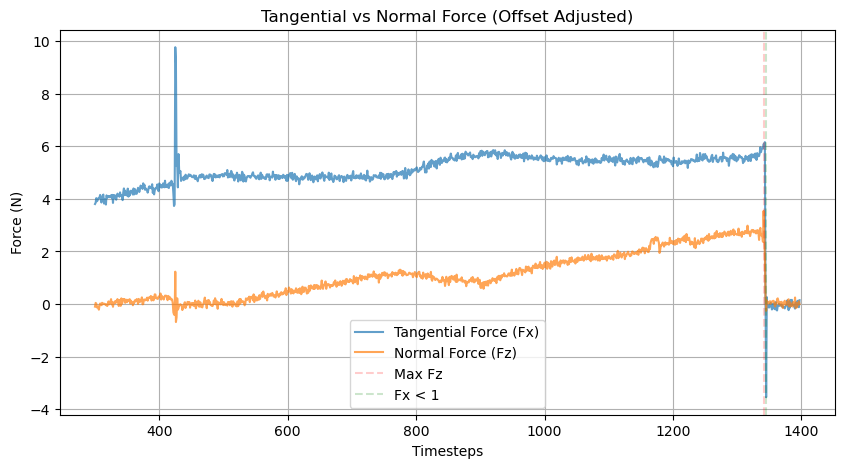

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241706.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=300, cut_2=None, avg_end=1344, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 622
Average Fx in the averaging interval [650:1272]: 5.7359288940859
Average Fz in the averaging interval [650:1272]: 1.2391383392890039
Maximum Fz in the plotting interval [650:None]: 2.5163614908854166 at timestep 1233
Time step where Fx drops below 1: 1272


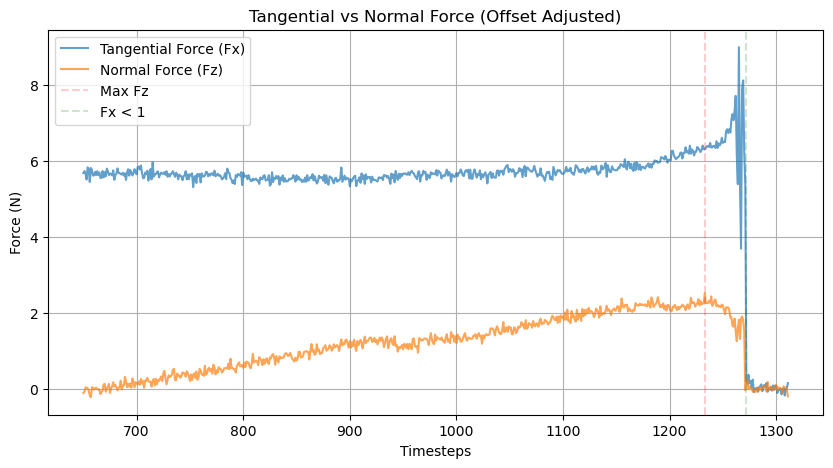

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241708.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=650, cut_2=None, avg_end=1272, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 629
Average Fx in the averaging interval [670:1299]: 5.320327904493517
Average Fz in the averaging interval [670:1299]: 0.5824567688667528
Maximum Fz in the plotting interval [670:None]: 2.59288330078125 at timestep 971
Time step where Fx drops below 0.1: 1299


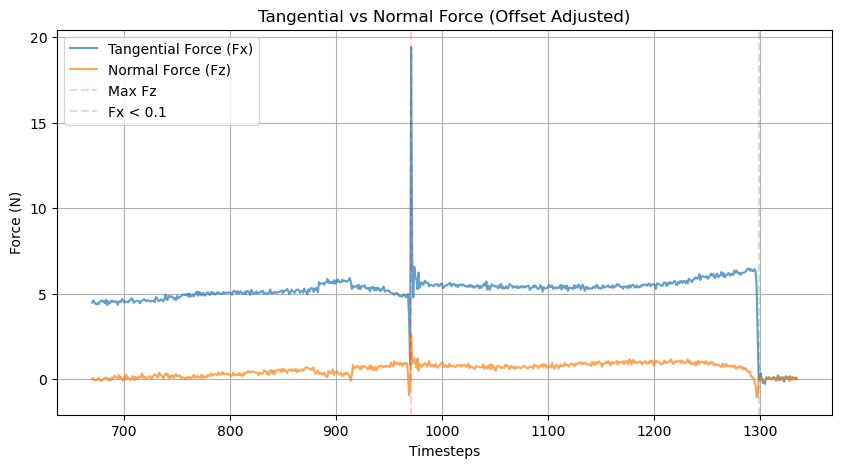

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241709.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=670, cut_2=None, avg_end=1299, offset_position='beginning', offset_length=15, fx_threshold=0.1)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 502
Average Fx in the averaging interval [400:902]: 3.2419993705166923
Average Fz in the averaging interval [400:902]: 0.407689837978814
Maximum Fz in the plotting interval [400:None]: 0.9296468098958334 at timestep 771
Time step where Fx drops below 1: 902


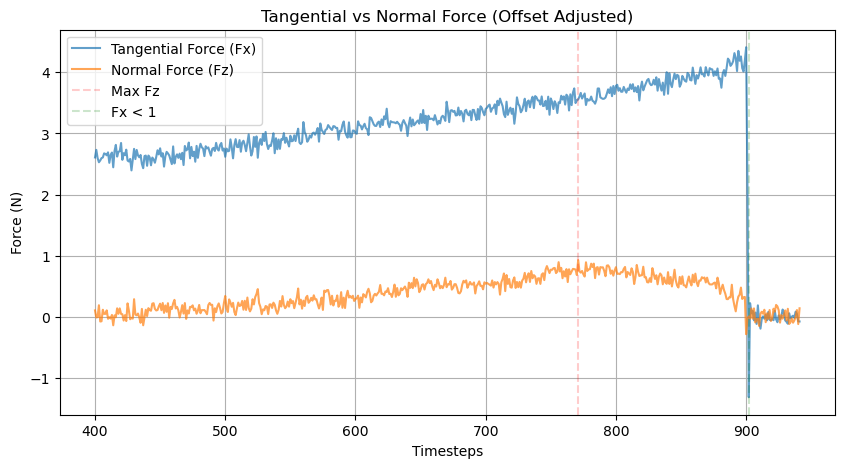

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241711.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=400, cut_2=None, avg_end=902, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 775
Average Fx in the averaging interval [220:995]: 5.051771617192094
Average Fz in the averaging interval [220:995]: 1.3088806283602152
Maximum Fz in the plotting interval [220:None]: 2.995963541666667 at timestep 986
Time step where Fx drops below 1: 995


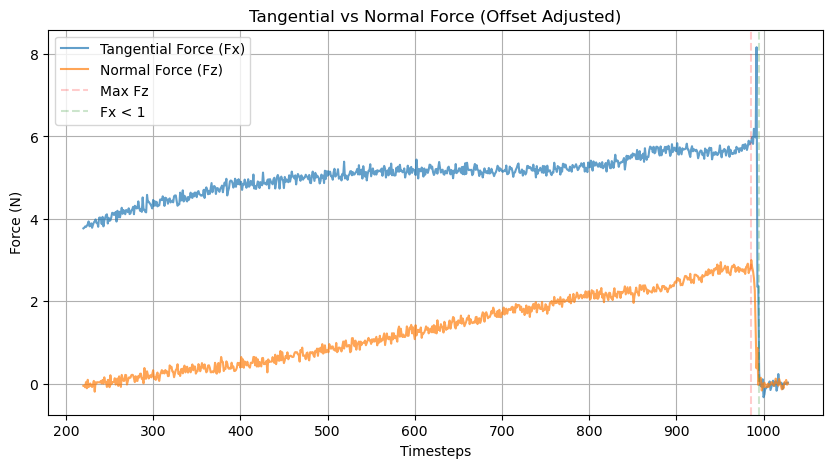

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241713.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=220, cut_2=None, avg_end=995, offset_position='end', offset_length=15)

<font size="6">Test 11: (worked)</font>

Length from cut_1 to avg_end: 759
Average Fx in the averaging interval [235:994]: 5.522159794165369
Average Fz in the averaging interval [235:994]: 0.8545372843585308
Maximum Fz in the plotting interval [235:None]: 1.7830525716145833 at timestep 924
Time step where Fx drops below 1: 994


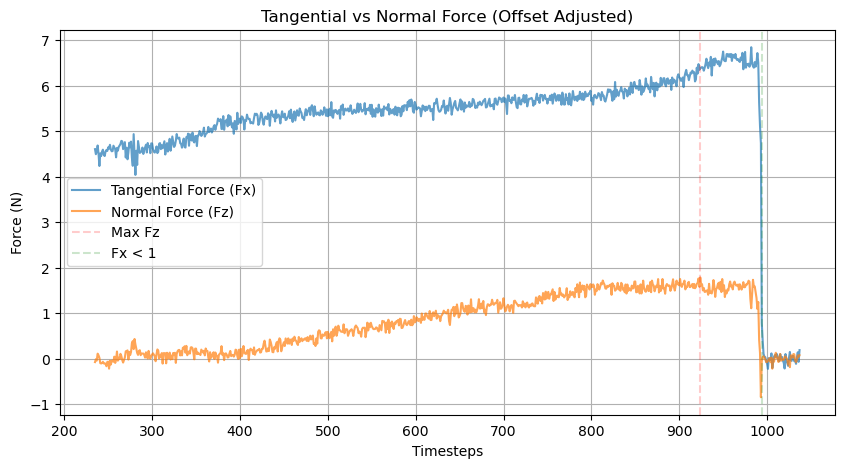

In [13]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_60_5N//log_202405241714.csv"
df = pd.read_csv(data)
test_11, end_11 = plot_forces(df, cut_1=235, cut_2=None, avg_end=994, offset_position='end', offset_length=15)

In [14]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [18]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//60//Asphalt_60_stats.csv", index=False)

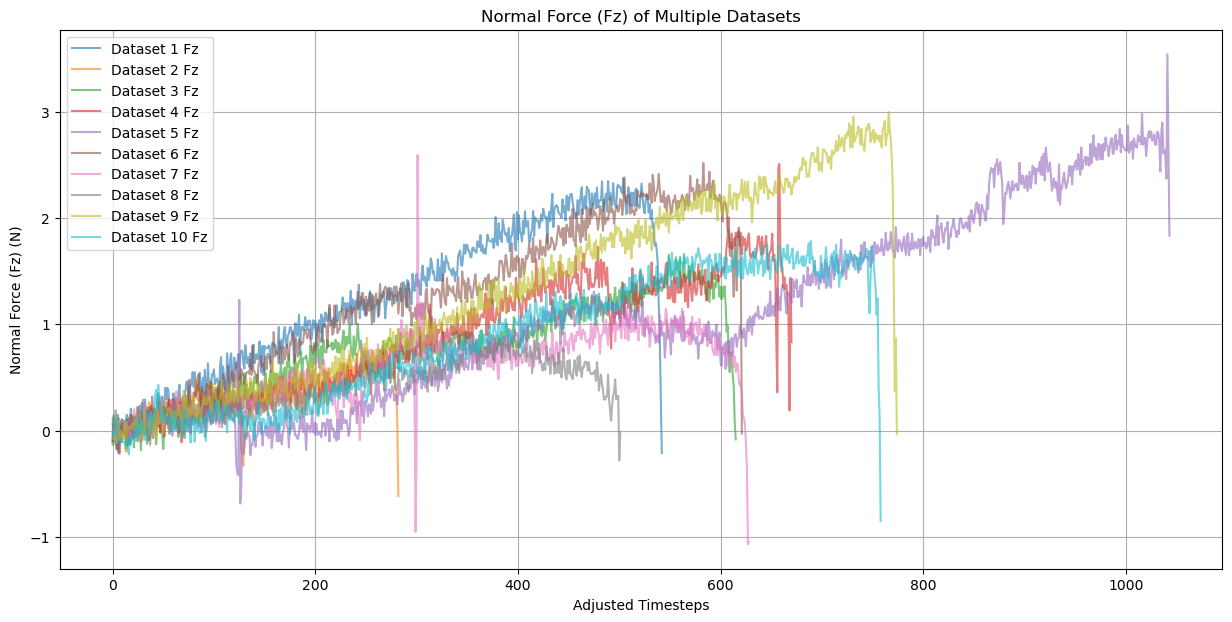

Average of maximum Fz forces: 2.167477213541667
Standard deviation of maximum Fz forces: 0.8307021115152545
Average of average Fz forces: 0.868611714879948
Standard deviation of average Fz forces: 0.3384954198015502
Average of average Fx forces: 5.046119320642535
Standard deviation of average Fx forces: 0.6590153367952801


In [19]:
tests = [test_2, test_3, test_4, test_5, test_6, test_7, test_8, test_9, test_10, test_11]
ends = [end_2, end_3, end_4, end_5, end_6, end_7, end_8, end_9, end_10, end_11]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [20]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//60//Asphalt_60"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)